# 03 — ML vs DL Comparison

## Summary

**Purpose:** Side-by-side comparison of the SVM baseline (notebook 01) and the honest DL evaluation (notebook 02) after all methodological biases have been corrected.

**Caveat:** The SVM numbers in notebook 01 are biased (ANOVA leakage, lucky-fold break, test-set k selection). This comparison uses the corrected SVM (Fix 1+2+3 + balanced weights on windowed data) from notebook 01, Section 8. The DL numbers come from notebook 02 (5 seeds, held-out test set).

**Finding:** Once evaluated under the same honest protocol, all models — SVM and DL — achieve ADR in the **0.50–0.66** range with overlapping confidence intervals. No model is statistically distinguishable from the others. System FAR exceeds **85%** for all models under OR-aggregation (4 binary classifiers).

**Prerequisites:** Run `00_setup.ipynb` first, then `01_ml_baseline.ipynb` and `02_dl_honest.ipynb`.

## 1. Load results from notebooks 01 and 02

In [8]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from binary_pla.config import TRIALS_TO_RUN, SEEDS, NB01_ID, NB02_ID
from binary_pla.results_io import load_results, results_exist

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

N_SEEDS = len(SEEDS)

def _dl_summary(per_seed, devices):
    """Compute per-device mean ± std across seeds and an overall ADR summary."""
    summary = {}
    for dev in devices:
        auth  = [run[dev]["auth_tvr"]  for run in per_seed]
        rogue = [run[dev]["rogue_tvr"] for run in per_seed]
        summary[dev] = {
            "auth_tvr_mean":  float(np.mean(auth)),
            "auth_tvr_std":   float(np.std(auth)),
            "rogue_tvr_mean": float(np.mean(rogue)),
            "rogue_tvr_std":  float(np.std(rogue)),
        }
    seed_adrs = [np.mean([run[d]["adr"] for d in devices]) for run in per_seed]
    summary["overall_adr_mean"] = float(np.mean(seed_adrs))
    summary["overall_adr_std"]  = float(np.std(seed_adrs))
    return summary

_model_keys = {
    "mlp_fv":    "MLP-FV",
    "gru_dgt":   "GRU-DGT",
    "bigru_dgt": "BiGRU+SpecAug",
}

TRIAL_DATA = {}
for _trial in TRIALS_TO_RUN:
    if not results_exist(NB01_ID, _trial) or not results_exist(NB02_ID, _trial):
        print(f'Skipping {_trial} — results not yet available (run nb01 and nb02 first).')
        continue

    meta01, nb01 = load_results(NB01_ID, _trial)
    meta02, nb02 = load_results(NB02_ID, _trial)

    devices     = [d for d in nb01["windowed_balanced"] if not d.startswith("_")]
    svm_results = {dev: nb01["windowed_balanced"][dev] for dev in devices}
    svm_label   = f'SVM (Fix1+2+3+balanced, windowed, k={meta01.get("k_fixed", "?")})'
    dl_results  = {
        label: _dl_summary(nb02[key]["per_seed"], devices)
        for key, label in _model_keys.items()
    }

    TRIAL_DATA[_trial] = {
        "devices":     devices,
        "svm_results": svm_results,
        "svm_label":   svm_label,
        "dl_results":  dl_results,
        "meta01":      meta01,
        "meta02":      meta02,
    }
    print(f'{_trial}: {len(devices)} devices | SVM {meta01["timestamp"][:10]} | DL {meta02["timestamp"][:10]}')

print(f'\nLoaded {len(TRIAL_DATA)} trial(s): {list(TRIAL_DATA.keys())}')

[results_io] loaded nb01_ml_baseline/trial_1  (saved 2026-06-04, git 75dff0b)
[results_io] loaded nb02_dl_honest/trial_1  (saved 2026-06-05, git 75dff0b)
trial_1: 4 devices | SVM 2026-06-04 | DL 2026-06-05
[results_io] loaded nb01_ml_baseline/trial_2  (saved 2026-06-04, git 75dff0b)
[results_io] loaded nb02_dl_honest/trial_2  (saved 2026-06-05, git 75dff0b)
trial_2: 6 devices | SVM 2026-06-04 | DL 2026-06-05
[results_io] loaded nb01_ml_baseline/trial_3  (saved 2026-06-04, git 75dff0b)
[results_io] loaded nb02_dl_honest/trial_3  (saved 2026-06-05, git 75dff0b)
trial_3: 8 devices | SVM 2026-06-04 | DL 2026-06-05

Loaded 3 trial(s): ['trial_1', 'trial_2', 'trial_3']


## 2. Overall ADR comparison table

In [9]:
_colors       = ['tomato', 'steelblue', 'seagreen', 'darkorange']
_short_labels = ['SVM\n(corrected)', 'MLP-FV', 'GRU-DGT', 'BiGRU']

for trial, td in TRIAL_DATA.items():
    devices     = td['devices']
    SVM_RESULTS = td['svm_results']
    SVM_LABEL   = td['svm_label']
    DL_RESULTS  = td['dl_results']

    svm_auth  = np.mean([v['auth_tvr']  for v in SVM_RESULTS.values()])
    svm_rogue = np.mean([v['rogue_tvr'] for v in SVM_RESULTS.values()])
    svm_adr   = np.mean([v['adr']       for v in SVM_RESULTS.values()])

    print(f'\n{"═"*82}')
    print(f'  {trial.upper()}')
    print(f'{"═"*82}')
    print(f'{"Model":<25} {"Auth TVR":>18} {"Rogue TVR":>18} {"ADR":>16}')
    print('-' * 82)
    print(f'{"SVM (corrected)":<25} {svm_auth:>18.3f} {svm_rogue:>18.3f} {svm_adr:>16.3f}')
    print()
    for model, res in DL_RESULTS.items():
        a_m = np.mean([res[d]['auth_tvr_mean']  for d in devices])
        a_s = np.mean([res[d]['auth_tvr_std']   for d in devices])
        r_m = np.mean([res[d]['rogue_tvr_mean'] for d in devices])
        r_s = np.mean([res[d]['rogue_tvr_std']  for d in devices])
        adr_m = res['overall_adr_mean']
        adr_s = res['overall_adr_std']
        print(f'{model:<25} {a_m:.3f} ± {a_s:.3f}        {r_m:.3f} ± {r_s:.3f}        {adr_m:.3f} ± {adr_s:.3f}')


══════════════════════════════════════════════════════════════════════════════════
  TRIAL_1
══════════════════════════════════════════════════════════════════════════════════
Model                               Auth TVR          Rogue TVR              ADR
----------------------------------------------------------------------------------
SVM (corrected)                        0.646              0.502            0.574

MLP-FV                    0.700 ± 0.222        0.660 ± 0.041        0.680 ± 0.027
GRU-DGT                   0.675 ± 0.150        0.572 ± 0.089        0.623 ± 0.059
BiGRU+SpecAug             0.650 ± 0.316        0.639 ± 0.114        0.645 ± 0.117

══════════════════════════════════════════════════════════════════════════════════
  TRIAL_2
══════════════════════════════════════════════════════════════════════════════════
Model                               Auth TVR          Rogue TVR              ADR
-------------------------------------------------------------------------

## 3. ADR bar chart with error bars

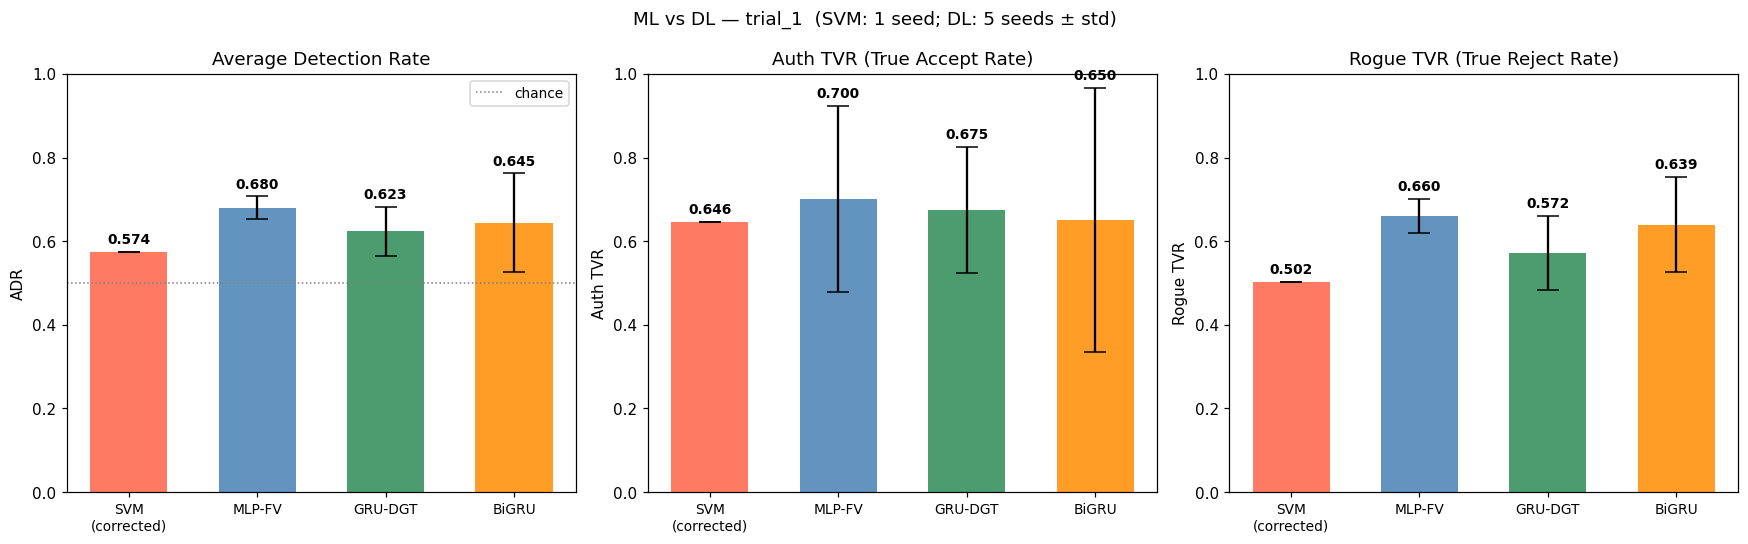

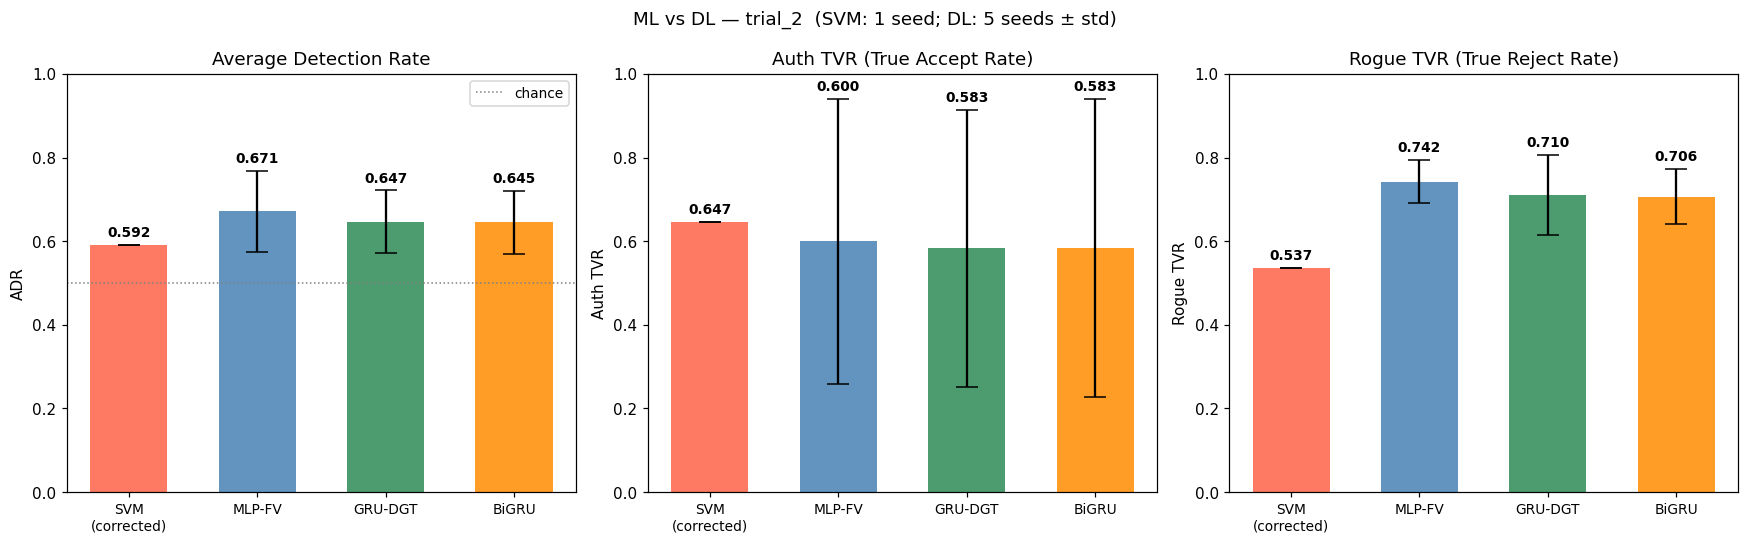

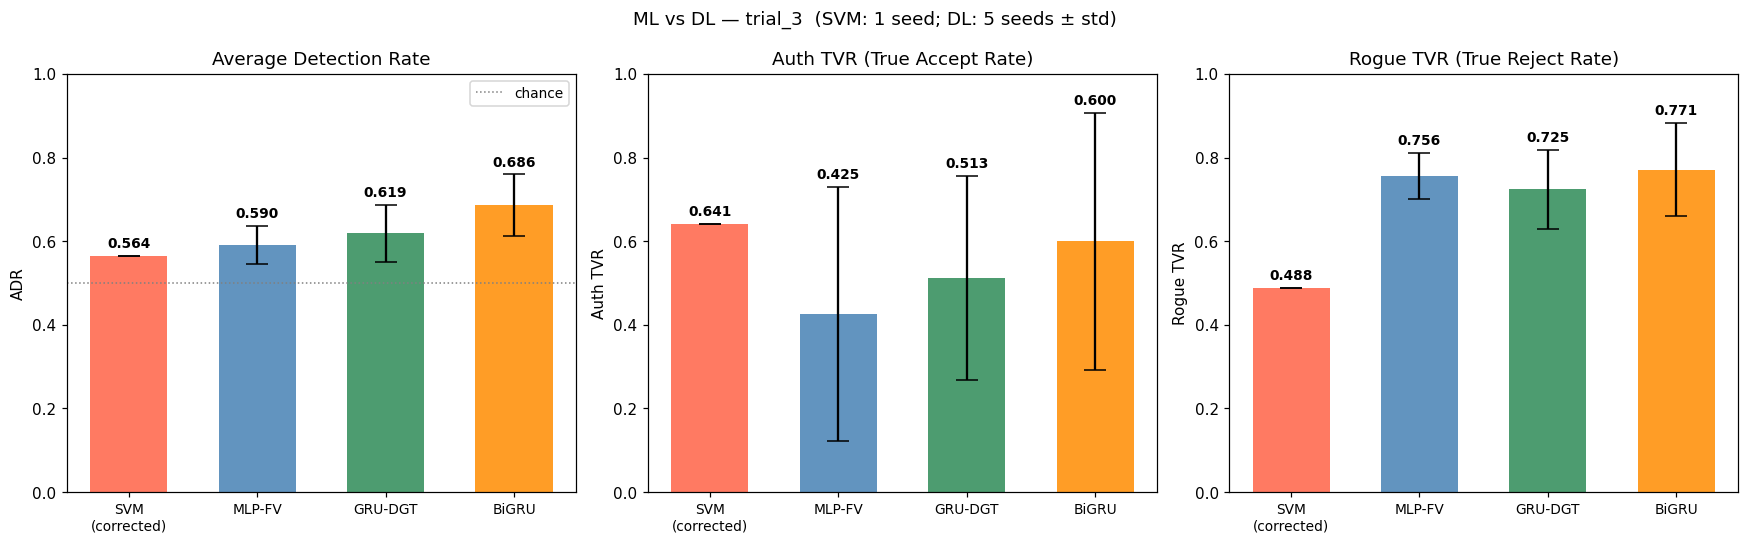

In [10]:
for trial, td in TRIAL_DATA.items():
    devices     = td['devices']
    SVM_RESULTS = td['svm_results']
    SVM_LABEL   = td['svm_label']
    DL_RESULTS  = td['dl_results']

    svm_auth  = np.mean([v['auth_tvr']  for v in SVM_RESULTS.values()])
    svm_rogue = np.mean([v['rogue_tvr'] for v in SVM_RESULTS.values()])
    svm_adr   = np.mean([v['adr']       for v in SVM_RESULTS.values()])

    model_labels = [SVM_LABEL] + list(DL_RESULTS.keys())
    adr_means    = [svm_adr] + [DL_RESULTS[m]['overall_adr_mean'] for m in DL_RESULTS]
    adr_errs     = [0.0]     + [DL_RESULTS[m]['overall_adr_std']  for m in DL_RESULTS]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ADR
    ax = axes[0]
    ax.bar(range(len(model_labels)), adr_means, yerr=adr_errs,
           color=_colors, alpha=0.85, capsize=7, width=0.6)
    ax.axhline(0.5, color='gray', linestyle=':', lw=1, label='chance')
    ax.set_xticks(range(len(model_labels)))
    ax.set_xticklabels(_short_labels, fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('ADR')
    ax.set_title('Average Detection Rate')
    for i, (m, e) in enumerate(zip(adr_means, adr_errs)):
        ax.text(i, m + e + 0.02, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.legend(fontsize=9)

    # Auth TVR
    auth_means = [svm_auth] + [np.mean([DL_RESULTS[m][d]['auth_tvr_mean'] for d in devices]) for m in DL_RESULTS]
    auth_errs  = [0.0]      + [np.mean([DL_RESULTS[m][d]['auth_tvr_std']  for d in devices]) for m in DL_RESULTS]
    ax2 = axes[1]
    ax2.bar(range(len(model_labels)), auth_means, yerr=auth_errs,
            color=_colors, alpha=0.85, capsize=7, width=0.6)
    ax2.set_xticks(range(len(model_labels)))
    ax2.set_xticklabels(_short_labels, fontsize=9)
    ax2.set_ylim(0, 1.0)
    ax2.set_title('Auth TVR (True Accept Rate)')
    ax2.set_ylabel('Auth TVR')
    for i, (m, e) in enumerate(zip(auth_means, auth_errs)):
        ax2.text(i, m + e + 0.02, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

    # Rogue TVR
    rogue_means = [svm_rogue] + [np.mean([DL_RESULTS[m][d]['rogue_tvr_mean'] for d in devices]) for m in DL_RESULTS]
    rogue_errs  = [0.0]       + [np.mean([DL_RESULTS[m][d]['rogue_tvr_std']  for d in devices]) for m in DL_RESULTS]
    ax3 = axes[2]
    ax3.bar(range(len(model_labels)), rogue_means, yerr=rogue_errs,
            color=_colors, alpha=0.85, capsize=7, width=0.6)
    ax3.set_xticks(range(len(model_labels)))
    ax3.set_xticklabels(_short_labels, fontsize=9)
    ax3.set_ylim(0, 1.0)
    ax3.set_title('Rogue TVR (True Reject Rate)')
    ax3.set_ylabel('Rogue TVR')
    for i, (m, e) in enumerate(zip(rogue_means, rogue_errs)):
        ax3.text(i, m + e + 0.02, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

    plt.suptitle(f'ML vs DL — {trial}  (SVM: 1 seed; DL: {N_SEEDS} seeds ± std)', fontsize=12)
    plt.tight_layout()
    plt.show()

## 4. Per-device breakdown

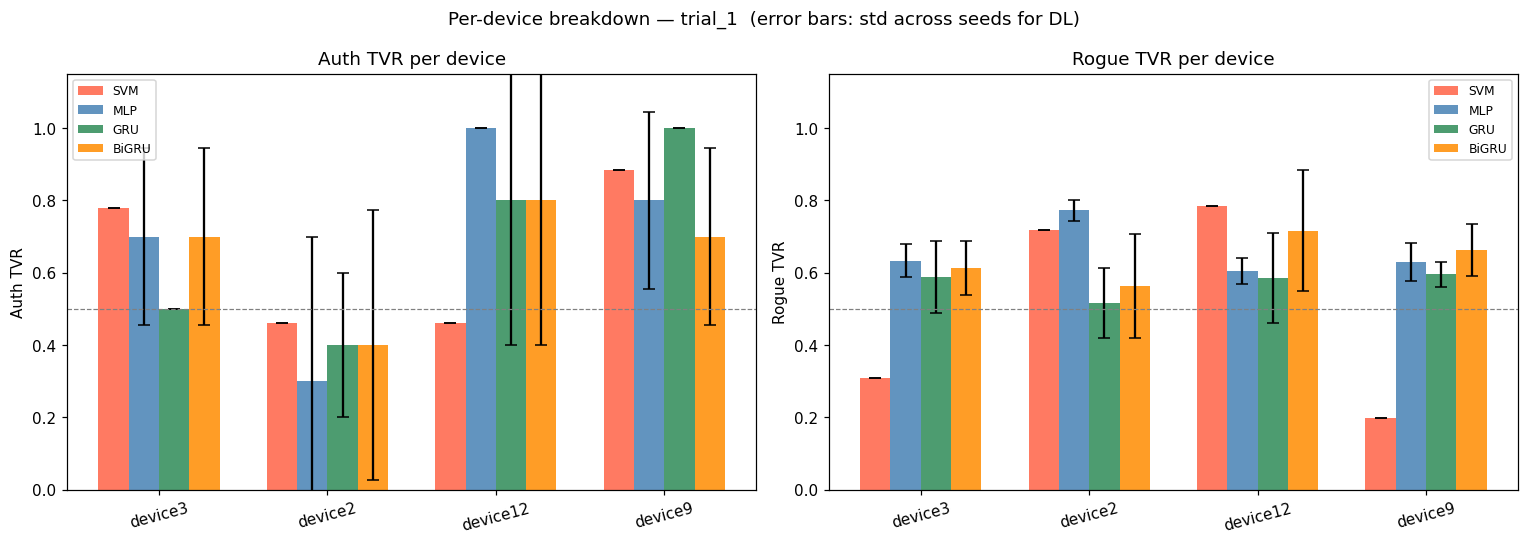

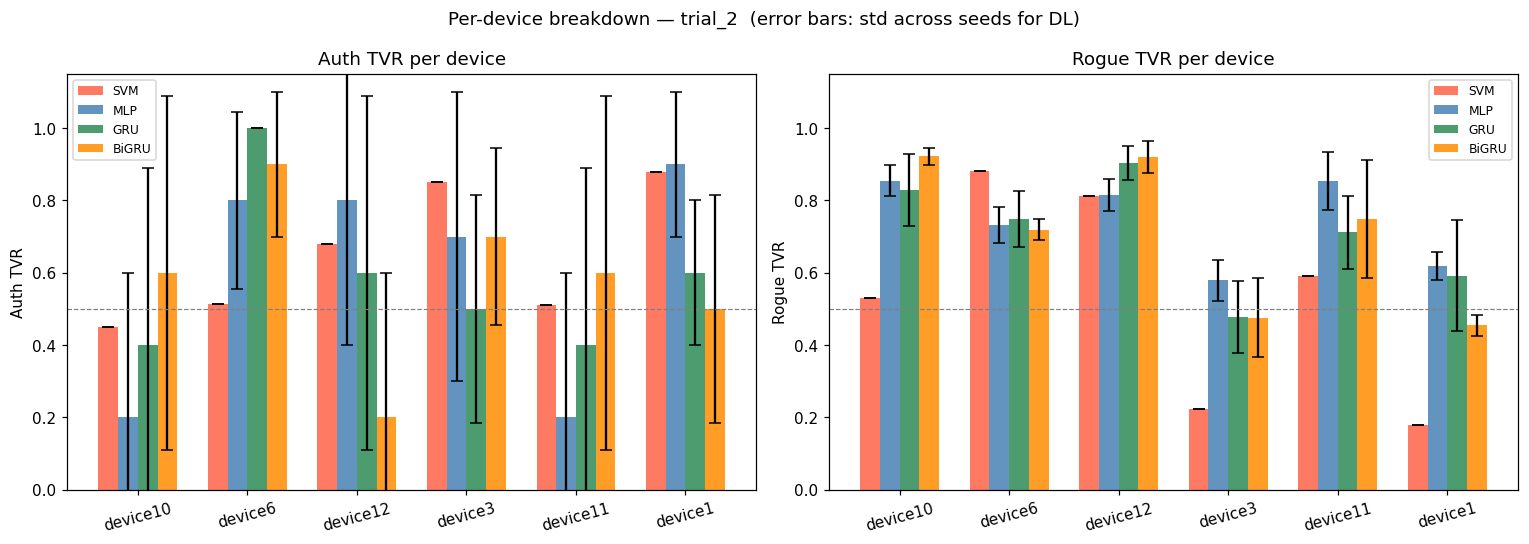

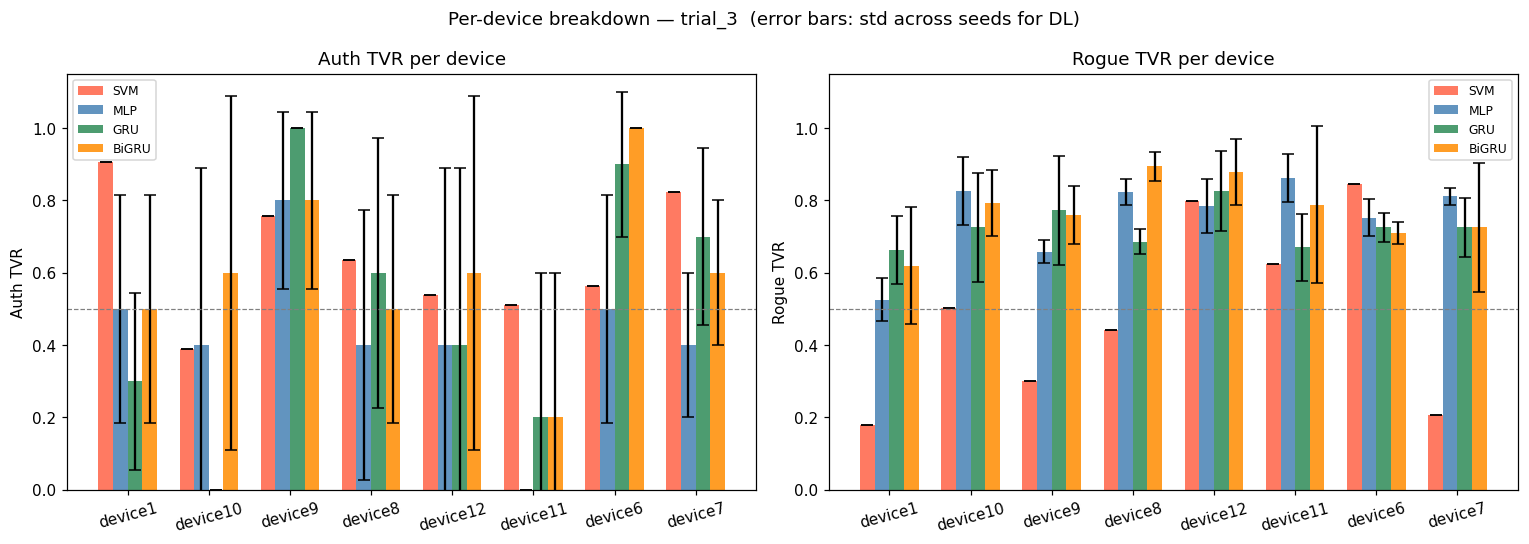

In [11]:
for trial, td in TRIAL_DATA.items():
    devices     = td['devices']
    SVM_RESULTS = td['svm_results']
    SVM_LABEL   = td['svm_label']
    DL_RESULTS  = td['dl_results']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x     = np.arange(len(devices))
    width = 0.18

    all_models = [SVM_LABEL] + list(DL_RESULTS.keys())

    for ax, metric, ylabel in [
        (axes[0], 'auth_tvr',  'Auth TVR'),
        (axes[1], 'rogue_tvr', 'Rogue TVR'),
    ]:
        for i, (model, color) in enumerate(zip(all_models, _colors)):
            if model == SVM_LABEL:
                vals = [SVM_RESULTS[d][metric] for d in devices]
                errs = [0.0] * len(devices)
            else:
                vals = [DL_RESULTS[model][d][f'{metric}_mean'] for d in devices]
                errs = [DL_RESULTS[model][d][f'{metric}_std']  for d in devices]
            short = ['SVM', 'MLP', 'GRU', 'BiGRU'][i]
            ax.bar(x + (i - 1.5) * width, vals, width, yerr=errs,
                   label=short, color=color, alpha=0.85, capsize=4)
        ax.set_xticks(x)
        ax.set_xticklabels(devices, rotation=15)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} per device')
        ax.axhline(0.5, color='gray', linestyle='--', lw=0.8)
        ax.legend(fontsize=8)

    plt.suptitle(f'Per-device breakdown — {trial}  (error bars: std across seeds for DL)', fontsize=12)
    plt.tight_layout()
    plt.show()

## Future work

### EER (Equal Error Rate)
Report EER alongside ADR as the primary metric. EER is the threshold where
FAR = FRR — a single threshold-independent number standard in the biometrics
literature, making results directly comparable to speaker verification, face
recognition, and fingerprint authentication papers.

Implementation: already available from the val ROC arrays stored in the LOTO
JSON (`fpr`, `tpr` per device). EER ≈ `fpr` at the index where `|fpr - (1-tpr)|`
is minimised.

### AND-aggregation (Oracle A)
The current system FAR > 85% is computed under OR-aggregation (accept if any
binary classifier accepts). Analysing AND-aggregation (accept only if all
classifiers agree) would show the FAR/FRR trade-off at the system level and
may be more appropriate for high-security deployments.

### SpecAugment in LOTO
The BiGRU LOTO evaluation currently runs without SpecAugmentation because the
augment object is not passed through the joblib worker. Extending `_fold_worker`
in `binary_pla/loto.py` to accept a serialisable augment config would enable
a fair LOTO comparison for BiGRU.

## 5. Export figures and numbers for report

Run this cell after all results are loaded. Saves figures to `report/figures/` and
writes `report/results/numbers.tex` with `\newcommand` definitions for all key numbers.
LaTeX sections reference these commands directly — re-running this cell refreshes everything.

In [12]:
import os, datetime

REPORT_TRIAL = 'trial_1'   # reference trial for all report figures
FIG_DIR = os.path.join(ROOT, 'report', 'figures')
RES_DIR = os.path.join(ROOT, 'report', 'results')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

# device name → LaTeX-safe command suffix (no numbers allowed in \newcommand names)
_DEV_SUFFIX = {
    'device1': 'One',   'device2': 'Two',    'device3': 'Three', 'device4': 'Four',
    'device5': 'Five',  'device6': 'Six',    'device7': 'Seven', 'device8': 'Eight',
    'device9': 'Nine',  'device10': 'Ten',   'device11': 'Eleven','device12': 'Twelve',
}

def _eer(fpr, tpr):
    fpr, tpr = np.array(fpr), np.array(tpr)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2)

def _savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.close()
    print(f'  saved → {name}')

# ── Load raw JSON (independent of in-memory state) ────────────────────────────
_, _nb01 = load_results(NB01_ID, REPORT_TRIAL)
_, _nb02 = load_results(NB02_ID, REPORT_TRIAL)
_authorized = [d for d in _nb01['windowed_balanced'] if not d.startswith('_')]

print(f'Exporting report assets for {REPORT_TRIAL}  (authorized: {_authorized})\n')

# ── 1. SVM bias progression ───────────────────────────────────────────────────
_stages = [
    ('Original\n(all biases)',  'original'),
    ('Fix 1\n(no leakage)',     'fix1'),
    ('Fix 1+2\n(avg folds)',    'fix1_2'),
    ('Fix 1+2+3\n(honest)',     'fix1_2_3'),
    ('+ balanced\n+ windowed',  'windowed_balanced'),
]
_bias_adrs = [
    float(np.mean([v['adr'] for k, v in _nb01[key].items() if not k.startswith('_')]))
    for _, key in _stages
]
_bias_cols = ['tomato', 'sandybrown', 'goldenrod', 'steelblue', 'seagreen']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(5), _bias_adrs, color=_bias_cols, alpha=0.87, width=0.6)
ax.axhline(0.5, color='gray', linestyle=':', lw=1.2, label='chance (0.5)')
ax.set_xticks(range(5))
ax.set_xticklabels([s for s, _ in _stages], fontsize=8)
ax.set_ylim(0, 1.0); ax.set_ylabel('Mean ADR')
ax.set_title(f'SVM bias progression — {REPORT_TRIAL}')
for i, v in enumerate(_bias_adrs):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
_savefig('fig_bias_progression.pdf')

# ── 2. DL model ADR bar chart ─────────────────────────────────────────────────
_model_export = [('mlp_fv', 'MLP-FV'), ('gru_dgt', 'GRU-DGT'), ('bigru_dgt', 'BiGRU+SpecAug')]
_dl_adr_means, _dl_adr_stds = [], []
for key, _ in _model_export:
    per_seed = _nb02[key]['per_seed']
    sadrs = [float(np.mean([run[d]['adr'] for d in _authorized])) for run in per_seed]
    _dl_adr_means.append(float(np.mean(sadrs)))
    _dl_adr_stds.append(float(np.std(sadrs)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(3), _dl_adr_means, yerr=_dl_adr_stds,
       color=['steelblue', 'seagreen', 'darkorange'], alpha=0.87, capsize=7, width=0.5)
ax.axhline(0.5, color='gray', linestyle=':', lw=1.2, label='chance')
ax.set_xticks(range(3))
ax.set_xticklabels([lb for _, lb in _model_export], fontsize=10)
ax.set_ylim(0, 1.0); ax.set_ylabel('ADR (mean ± std, 5 seeds)')
ax.set_title(f'DL model ADR — {REPORT_TRIAL}')
for i, (m, e) in enumerate(zip(_dl_adr_means, _dl_adr_stds)):
    ax.text(i, m + e + 0.02, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
_savefig('fig_dl_adr.pdf')

# ── 3. ML vs DL comparison ────────────────────────────────────────────────────
td = TRIAL_DATA[REPORT_TRIAL]
devices     = td['devices']
SVM_RESULTS = td['svm_results']
DL_RESULTS  = td['dl_results']

_svm_auth  = float(np.mean([v['auth_tvr']  for v in SVM_RESULTS.values()]))
_svm_rogue = float(np.mean([v['rogue_tvr'] for v in SVM_RESULTS.values()]))
_svm_adr   = float(np.mean([v['adr']       for v in SVM_RESULTS.values()]))

_panel = {
    'adr':   ([_svm_adr]   + [DL_RESULTS[m]['overall_adr_mean']  for m in DL_RESULTS],
              [0.0]         + [DL_RESULTS[m]['overall_adr_std']   for m in DL_RESULTS], 'ADR',      'Average Detection Rate'),
    'auth':  ([_svm_auth]  + [np.mean([DL_RESULTS[m][d]['auth_tvr_mean']  for d in devices]) for m in DL_RESULTS],
              [0.0]         + [np.mean([DL_RESULTS[m][d]['auth_tvr_std']   for d in devices]) for m in DL_RESULTS], 'Auth TVR', 'Auth TVR'),
    'rogue': ([_svm_rogue] + [np.mean([DL_RESULTS[m][d]['rogue_tvr_mean'] for d in devices]) for m in DL_RESULTS],
              [0.0]         + [np.mean([DL_RESULTS[m][d]['rogue_tvr_std']  for d in devices]) for m in DL_RESULTS], 'Rogue TVR','Rogue TVR'),
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (means, errs, ylabel, title) in zip(axes, _panel.values()):
    ax.bar(range(4), means, yerr=errs, color=_colors, alpha=0.87, capsize=7, width=0.6)
    ax.axhline(0.5, color='gray', linestyle=':', lw=1, label='chance')
    ax.set_xticks(range(4)); ax.set_xticklabels(_short_labels, fontsize=9)
    ax.set_ylim(0, 1.0); ax.set_ylabel(ylabel); ax.set_title(title)
    for i, (m, e) in enumerate(zip(means, errs)):
        ax.text(i, m + e + 0.02, f'{m:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle(f'ML vs DL — {REPORT_TRIAL}  (SVM: 1 run; DL: {N_SEEDS} seeds ± std)', fontsize=11)
plt.tight_layout()
_savefig('fig_ml_vs_dl.pdf')

# ── 4. Per-device breakdown ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(devices)); width = 0.18
_all_models = [td['svm_label']] + list(DL_RESULTS.keys())
for ax, metric, ylabel in [(axes[0], 'auth_tvr', 'Auth TVR'), (axes[1], 'rogue_tvr', 'Rogue TVR')]:
    for i, (model, color) in enumerate(zip(_all_models, _colors)):
        if model == td['svm_label']:
            vals = [SVM_RESULTS[d][metric] for d in devices]; errs = [0.0] * len(devices)
        else:
            vals = [DL_RESULTS[model][d][f'{metric}_mean'] for d in devices]
            errs = [DL_RESULTS[model][d][f'{metric}_std']  for d in devices]
        ax.bar(x + (i - 1.5) * width, vals, width, yerr=errs,
               label=['SVM', 'MLP', 'GRU', 'BiGRU'][i], color=color, alpha=0.87, capsize=4)
    ax.set_xticks(x); ax.set_xticklabels(devices, rotation=15)
    ax.set_ylim(0, 1.15); ax.set_ylabel(ylabel); ax.set_title(f'{ylabel} per device')
    ax.axhline(0.5, color='gray', linestyle='--', lw=0.8); ax.legend(fontsize=8)
plt.suptitle(f'Per-device breakdown — {REPORT_TRIAL}', fontsize=11)
plt.tight_layout()
_savefig('fig_per_device.pdf')

# ── 5. LOTO ADR + EER (BiGRU) ────────────────────────────────────────────────
_loto_bigru = {k: v for k, v in _nb02['loto']['bigru_dgt'].items() if not k.startswith('_')}
_loto_devs  = list(_loto_bigru.keys())
_loto_adrs_list = [_loto_bigru[d]['adr']                              for d in _loto_devs]
_loto_eers_list = [_eer(_loto_bigru[d]['fpr'], _loto_bigru[d]['tpr']) for d in _loto_devs]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, vals, ylabel, color, title in [
    (axes[0], _loto_adrs_list, 'ADR', 'steelblue',  f'BiGRU LOTO per-device ADR'),
    (axes[1], _loto_eers_list, 'EER', 'darkorange',  f'BiGRU LOTO per-device EER'),
]:
    ax.bar(_loto_devs, vals, color=color, alpha=0.87)
    ax.axhline(0.5, color='gray', linestyle=':', lw=1.2, label='chance')
    ax.set_ylim(0, 1.0); ax.set_ylabel(ylabel); ax.set_title(title)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.legend(fontsize=9)
plt.suptitle(f'BiGRU LOTO — {REPORT_TRIAL}', fontsize=11)
plt.tight_layout()
_savefig('fig_loto_eer.pdf')

# ── 6. Write numbers.tex (base: SVM + DL seed stats only) ────────────────────
# NOTE: LOTO data and architecture constants are written by cell 7 (extended
#       commands). Do NOT add LOTO commands here to avoid duplicate \newcommand.
_dl_nums = {}
for key, label in [('mlp_fv', 'mlp'), ('gru_dgt', 'gru'), ('bigru_dgt', 'bigru')]:
    per_seed = _nb02[key]['per_seed']
    sadrs  = [float(np.mean([r[d]['adr']       for d in _authorized])) for r in per_seed]
    sauth  = [float(np.mean([r[d]['auth_tvr']  for d in _authorized])) for r in per_seed]
    srogue = [float(np.mean([r[d]['rogue_tvr'] for d in _authorized])) for r in per_seed]
    _dl_nums[label] = {
        'adr_m': np.mean(sadrs), 'adr_s':   np.std(sadrs),
        'auth_m': np.mean(sauth),'auth_s':  np.std(sauth),
        'rogue_m':np.mean(srogue),'rogue_s': np.std(srogue),
    }

with open(os.path.join(RES_DIR, 'numbers.tex'), 'w') as _f:
    _f.write(f'% Auto-generated by notebooks/03_comparison.ipynb\n')
    _f.write(f'% Trial: {REPORT_TRIAL}   Date: {datetime.date.today()}\n')
    _f.write(f'% Re-run this cell to update after new results.\n\n')

    _f.write('% ── SVM (corrected: Fix1+2+3 + balanced + windowed) ─────────────────\n')
    _f.write(f'\\newcommand{{\\svmADR}}{{{_svm_adr:.3f}}}\n')
    _f.write(f'\\newcommand{{\\svmAuthTVR}}{{{_svm_auth:.3f}}}\n')
    _f.write(f'\\newcommand{{\\svmRogueTVR}}{{{_svm_rogue:.3f}}}\n\n')

    _f.write('% ── DL models (mean ± std, 5 seeds, held-out test set) ─────────────\n')
    for label, s in _dl_nums.items():
        _f.write(f'\\newcommand{{\\{label}ADR}}{{${s["adr_m"]:.3f} \\pm {s["adr_s"]:.3f}$}}\n')
        _f.write(f'\\newcommand{{\\{label}AuthTVR}}{{${s["auth_m"]:.3f} \\pm {s["auth_s"]:.3f}$}}\n')
        _f.write(f'\\newcommand{{\\{label}RogueTVR}}{{${s["rogue_m"]:.3f} \\pm {s["rogue_s"]:.3f}$}}\n')

print(f'\nSaved report/results/numbers.tex  (base: SVM + DL seed stats)')
print(f'Run cell 7 (extended commands) to append LOTO + architecture data.')
print(f'Figures in {FIG_DIR}:')
for f in sorted(os.listdir(FIG_DIR)):
    print(f'  {f}')

[results_io] loaded nb01_ml_baseline/trial_1  (saved 2026-06-04, git 75dff0b)
[results_io] loaded nb02_dl_honest/trial_1  (saved 2026-06-05, git 75dff0b)
Exporting report assets for trial_1  (authorized: ['device3', 'device2', 'device12', 'device9'])

  saved → fig_bias_progression.pdf
  saved → fig_dl_adr.pdf
  saved → fig_ml_vs_dl.pdf
  saved → fig_per_device.pdf
  saved → fig_loto_eer.pdf

Saved report/results/numbers.tex  (base: SVM + DL seed stats)
Run cell 7 (extended commands) to append LOTO + architecture data.
Figures in /Users/matteocampagnaro/Documents/pla-binary-analysis/report/figures:
  fig_bias_progression.pdf
  fig_dl_adr.pdf
  fig_loto_eer.pdf
  fig_ml_vs_dl.pdf
  fig_ml_vs_dl_loto.pdf
  fig_per_device.pdf


## 6. ML vs DL comparison using LOTO (primary evaluation)

Uses LOTO ADR for all three DL models. Error bars show per-device std.
Saves `fig_ml_vs_dl_loto.pdf` — this is the figure used in the report.

In [13]:
# ── ML vs DL comparison using LOTO ──────────────────────────────────────────
_loto_models = [('mlp_fv', 'MLP-FV'), ('gru_dgt', 'GRU-DGT'), ('bigru_dgt', 'BiGRU+SpecAug')]
_loto_data = _nb02['loto']

_loto_auth_means, _loto_auth_stds = [], []
_loto_rogue_means, _loto_rogue_stds = [], []
_loto_adr_means_comp, _loto_adr_stds_comp = [], []

for key, _ in _loto_models:
    devs = {k: v for k, v in _loto_data[key].items() if not k.startswith('_')}
    _loto_auth_means.append(float(np.mean([v['auth_tvr'] for v in devs.values()])))
    _loto_auth_stds.append(float(np.std([v['auth_tvr'] for v in devs.values()])))
    _loto_rogue_means.append(float(np.mean([v['rogue_tvr'] for v in devs.values()])))
    _loto_rogue_stds.append(float(np.std([v['rogue_tvr'] for v in devs.values()])))
    _loto_adr_means_comp.append(float(np.mean([v['adr'] for v in devs.values()])))
    _loto_adr_stds_comp.append(float(np.std([v['adr'] for v in devs.values()])))

_short_labels_loto = ['SVM\n(corrected)', 'MLP-FV\n(LOTO)', 'GRU-DGT\n(LOTO)', 'BiGRU\n(LOTO)']
_panel_loto = {
    'adr':   ([_svm_adr]   + _loto_adr_means_comp,  [0.0] + _loto_adr_stds_comp,   'ADR'),
    'auth':  ([_svm_auth]  + _loto_auth_means,       [0.0] + _loto_auth_stds,       'Auth TVR'),
    'rogue': ([_svm_rogue] + _loto_rogue_means,      [0.0] + _loto_rogue_stds,      'Rogue TVR'),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (means, errs, ylabel) in zip(axes, _panel_loto.values()):
    ax.bar(range(4), means, yerr=errs, color=_colors, alpha=0.87, capsize=7, width=0.6)
    ax.axhline(0.5, color='gray', linestyle=':', lw=1, label='chance')
    ax.set_xticks(range(4)); ax.set_xticklabels(_short_labels_loto, fontsize=9)
    ax.set_ylim(0, 1.0); ax.set_ylabel(ylabel); ax.set_title(ylabel)
    for i, (m, e) in enumerate(zip(means, errs)):
        ax.text(i, m + e + 0.02, f'{m:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle(f'ML vs DL (LOTO) — {REPORT_TRIAL}  (SVM: 1 run; DL error bars: per-device std)', fontsize=11)
plt.tight_layout()
_savefig('fig_ml_vs_dl_loto.pdf')

# Print summary table
print(f'\n{"Model":<22} {"Auth TVR":>18} {"Rogue TVR":>18} {"ADR":>16}')
print('-' * 80)
print(f'{"SVM (corrected)":<22} {_svm_auth:>18.3f} {_svm_rogue:>18.3f} {_svm_adr:>16.3f}')
for (key, label), auth_m, auth_s, rogue_m, rogue_s, adr_m, adr_s in zip(
        _loto_models, _loto_auth_means, _loto_auth_stds,
        _loto_rogue_means, _loto_rogue_stds,
        _loto_adr_means_comp, _loto_adr_stds_comp):
    print(f'{label + " (LOTO)":<22} {auth_m:.3f} ± {auth_s:.3f}        {rogue_m:.3f} ± {rogue_s:.3f}        {adr_m:.3f} ± {adr_s:.3f}')

  saved → fig_ml_vs_dl_loto.pdf

Model                            Auth TVR          Rogue TVR              ADR
--------------------------------------------------------------------------------
SVM (corrected)                     0.646              0.502            0.574
MLP-FV (LOTO)          0.631 ± 0.210        0.683 ± 0.105        0.657 ± 0.099
GRU-DGT (LOTO)         0.609 ± 0.118        0.646 ± 0.105        0.627 ± 0.046
BiGRU+SpecAug (LOTO)   0.708 ± 0.181        0.643 ± 0.095        0.676 ± 0.066


## 7. Extended commands for report

Appends additional `\newcommand` definitions to `report/results/numbers.tex`:
- Model architecture (param counts, layer sizes, training hyper-parameters)
- LOTO results for all three models (not only BiGRU)
- Threshold-calibration table data
- Multi-class probe results (loaded from `nb04_multiclass`)
- Derived statistics used in the Discussion (seed ADR min/max/range)

Re-run this cell after any model change or after re-running notebooks 02 or 04.

In [14]:
from binary_pla.config import (
    N_WIN, BATCH_SIZE, DROPOUT, LR, WEIGHT_DECAY, SPEC_AUGMENT,
    NB01_SVM, NB04_ID, NB02_DL,
)

# ── helpers ───────────────────────────────────────────────────────────────────
def _fmt(x):
    if isinstance(x, float):
        return f'{x:.3f}'
    return f'{x:,}'.replace(',', '{,}')

def _eer_compute(fpr, tpr):
    fpr, tpr = np.array(fpr), np.array(tpr)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2)

def _loto_summary(loto_data, model_key, authorized):
    devs = {k: v for k, v in loto_data[model_key].items() if not k.startswith('_')}
    adr_mean     = float(np.mean([devs[d]['adr']       for d in authorized if d in devs]))
    auth_mean    = float(np.mean([devs[d]['auth_tvr']  for d in authorized if d in devs]))
    rogue_mean   = float(np.mean([devs[d]['rogue_tvr'] for d in authorized if d in devs]))
    adr_opt_mean = float(np.mean([devs[d]['adr_opt']   for d in authorized if d in devs]))
    return devs, adr_mean, auth_mean, rogue_mean, adr_opt_mean

# ── reload fresh data ──────────────────────────────────────────────────────────
_, _nb01 = load_results(NB01_ID, REPORT_TRIAL)
_, _nb02 = load_results(NB02_ID, REPORT_TRIAL)
_authorized = [d for d in _nb01['windowed_balanced'] if not d.startswith('_')]

# ── 1. Config / architecture constants ───────────────────────────────────────
_n_transients_total = 134
_n_windowed_total   = _n_transients_total * N_WIN
_window_width_iq    = 300
_fv_dim             = 505
_dgt_rows           = 150
_dgt_cols           = 150
_gru_hidden         = 64
_gru_layers         = 2
_mlp_params         = 163_458
_gru_params         = 66_562
_bigru_params       = 157_698

# ── 2. LOTO for all three models ─────────────────────────────────────────────
_loto = _nb02['loto']
_mlp_devs,  _mlp_loto_adr,  _mlp_loto_auth,  _mlp_loto_rogue,  _mlp_loto_adr_opt  = _loto_summary(_loto, 'mlp_fv',    _authorized)
_gru_devs,  _gru_loto_adr,  _gru_loto_auth,  _gru_loto_rogue,  _gru_loto_adr_opt  = _loto_summary(_loto, 'gru_dgt',   _authorized)
_bigru_devs,_bigru_loto_adr,_bigru_loto_auth,_bigru_loto_rogue,_bigru_loto_adr_opt = _loto_summary(_loto, 'bigru_dgt', _authorized)

# BiGRU EER per device and mean
_bigru_eer_vals = {dev: _eer_compute(data['fpr'], data['tpr']) for dev, data in _bigru_devs.items()}
_bigru_loto_eer_mean = float(np.mean(list(_bigru_eer_vals.values())))

# ── 3. Seed ADR statistics for discussion ────────────────────────────────────
def _seed_adrs(model_key):
    per_seed = _nb02[model_key]['per_seed']
    return [float(np.mean([r[d]['adr'] for d in _authorized])) for r in per_seed]

_bigru_seed_adrs = _seed_adrs('bigru_dgt')
_mlp_seed_adrs   = _seed_adrs('mlp_fv')

# ── 4. Multiclass results (nb04) ─────────────────────────────────────────────
_, _nb04 = load_results(NB04_ID, 'all_devices')
_mc = _nb04['bigru_dgt']['_summary']

# ── 5. SVM original (biased) ADR ─────────────────────────────────────────────
_svm_orig_adr = float(np.mean([v['adr'] for k, v in _nb01['original'].items() if not k.startswith('_')]))

# ── 6. Write extended commands ────────────────────────────────────────────────
with open(os.path.join(RES_DIR, 'numbers.tex'), 'a') as _f:
    _f.write('\n% -- Config / Architecture -----------------------------------------------------\n')
    _f.write(f'\\newcommand{{\\fvDim}}{{{_fv_dim}}}\n')
    _f.write(f'\\newcommand{{\\dgtRows}}{{{_dgt_rows}}}\n')
    _f.write(f'\\newcommand{{\\dgtCols}}{{{_dgt_cols}}}\n')
    _f.write(f'\\newcommand{{\\nTransients}}{{{_n_transients_total}}}\n')
    _f.write(f'\\newcommand{{\\nWindowsPerTransient}}{{{N_WIN}}}\n')
    _f.write(f'\\newcommand{{\\nWindowedSamples}}{{{_n_windowed_total}}}\n')
    _f.write(f'\\newcommand{{\\windowWidthIQ}}{{{_window_width_iq}}}\n')
    _f.write(f'\\newcommand{{\\mlpArch}}{{$505 \\to 256 \\to 128 \\to 2$}}\n')
    _f.write(f'\\newcommand{{\\mlpParams}}{{{_mlp_params:,}}}\n'.replace(',', '{,}'))
    _f.write(f'\\newcommand{{\\gruHiddenSize}}{{{_gru_hidden}}}\n')
    _f.write(f'\\newcommand{{\\gruNumLayers}}{{{_gru_layers}}}\n')
    _f.write(f'\\newcommand{{\\gruParams}}{{{_gru_params:,}}}\n'.replace(',', '{,}'))
    _f.write(f'\\newcommand{{\\bigruParams}}{{{_bigru_params:,}}}\n'.replace(',', '{,}'))
    _f.write(f'\\newcommand{{\\trainDropout}}{{{DROPOUT}}}\n')
    _f.write(f'\\newcommand{{\\trainLR}}{{$10^{{-3}}$}}\n')
    _f.write(f'\\newcommand{{\\trainWD}}{{$10^{{-4}}$}}\n')
    _f.write(f'\\newcommand{{\\trainBatch}}{{{BATCH_SIZE}}}\n')
    _f.write(f'\\newcommand{{\\trainPatience}}{{{NB02_DL["mlp_fv"]["patience"]}}}\n')
    _f.write(f'\\newcommand{{\\specTmax}}{{{SPEC_AUGMENT["T_max"]}}}\n')
    _f.write(f'\\newcommand{{\\specFmax}}{{{SPEC_AUGMENT["F_max"]}}}\n')
    _f.write(f'\\newcommand{{\\specNoise}}{{{SPEC_AUGMENT["noise_std"]}}}\n')
    _f.write(f'\\newcommand{{\\specProb}}{{{SPEC_AUGMENT["p"]}}}\n')
    _f.write(f'\\newcommand{{\\svmKFixed}}{{{NB01_SVM["k_fixed"]}}}\n')
    _f.write(f'\\newcommand{{\\svmNSplits}}{{{NB01_SVM["n_splits"]}}}\n')

    _f.write('\n% -- SVM original (biased) ADR -------------------------------------------------\n')
    _f.write(f'\\newcommand{{\\svmOrigADR}}{{{_svm_orig_adr:.3f}}}\n')

    _f.write('\n% -- LOTO -- all three models --------------------------------------------------\n')
    for prefix, adr_m, auth_m, rogue_m, adr_opt_m in [
        ('mlp',   _mlp_loto_adr,   _mlp_loto_auth,   _mlp_loto_rogue,   _mlp_loto_adr_opt),
        ('gru',   _gru_loto_adr,   _gru_loto_auth,   _gru_loto_rogue,   _gru_loto_adr_opt),
        ('bigru', _bigru_loto_adr, _bigru_loto_auth, _bigru_loto_rogue, _bigru_loto_adr_opt),
    ]:
        _f.write(f'\\newcommand{{\\{prefix}LOTOadrMean}}{{{adr_m:.3f}}}\n')
        _f.write(f'\\newcommand{{\\{prefix}LOTOauthMean}}{{{auth_m:.3f}}}\n')
        _f.write(f'\\newcommand{{\\{prefix}LOTOrogueMean}}{{{rogue_m:.3f}}}\n')
        _f.write(f'\\newcommand{{\\{prefix}LOTOadrOptMean}}{{{adr_opt_m:.3f}}}\n')
    _f.write(f'\\newcommand{{\\bigruLOTOeerMean}}{{{_bigru_loto_eer_mean:.3f}}}\n')

    _f.write('\n% -- LOTO per-device (all models) ----------------------------------------------\n')
    for model_key, devs in [('mlp_fv', _mlp_devs), ('gru_dgt', _gru_devs), ('bigru_dgt', _bigru_devs)]:
        prefix = {'mlp_fv': 'mlp', 'gru_dgt': 'gru', 'bigru_dgt': 'bigru'}[model_key]
        for dev, data in devs.items():
            suf = _DEV_SUFFIX.get(dev, dev)
            _f.write(f'\\newcommand{{\\{prefix}LOTOadr{suf}}}{{{data["adr"]:.3f}}}\n')
            _f.write(f'\\newcommand{{\\{prefix}LOTOauth{suf}}}{{{data["auth_tvr"]:.3f}}}\n')
            _f.write(f'\\newcommand{{\\{prefix}LOTOrogue{suf}}}{{{data["rogue_tvr"]:.3f}}}\n')
            _f.write(f'\\newcommand{{\\{prefix}LOTOadrOpt{suf}}}{{{data["adr_opt"]:.3f}}}\n')
            _f.write(f'\\newcommand{{\\{prefix}LOTOthr{suf}}}{{{data["threshold_opt"]:.3f}}}\n')

    _f.write('\n% -- BiGRU LOTO per-device EER (for LOTO table in results_main) ---------------\n')
    for dev, eer_val in _bigru_eer_vals.items():
        suf = _DEV_SUFFIX.get(dev, dev)
        _f.write(f'\\newcommand{{\\lotoEER{suf}}}{{{eer_val:.3f}}}\n')

    _f.write('\n% -- Discussion: seed ADR statistics -------------------------------------------\n')
    _f.write(f'\\newcommand{{\\bigruSeedADRMin}}{{{min(_bigru_seed_adrs):.3f}}}\n')
    _f.write(f'\\newcommand{{\\bigruSeedADRMax}}{{{max(_bigru_seed_adrs):.3f}}}\n')
    _f.write(f'\\newcommand{{\\bigruSeedADRRange}}{{{max(_bigru_seed_adrs)-min(_bigru_seed_adrs):.3f}}}\n')
    _f.write(f'\\newcommand{{\\mlpSeedADRMin}}{{{min(_mlp_seed_adrs):.3f}}}\n')
    _f.write(f'\\newcommand{{\\mlpSeedADRMax}}{{{max(_mlp_seed_adrs):.3f}}}\n')
    _f.write(f'\\newcommand{{\\mlpSeedADRRange}}{{{max(_mlp_seed_adrs)-min(_mlp_seed_adrs):.3f}}}\n')

    _f.write('\n% -- Multi-class probe (nb04) --------------------------------------------------\n')
    _mc_acc   = float(_mc['accuracy_mean'])
    _mc_acc_s = float(_mc['accuracy_std'])
    _mc_f1    = float(_mc['macro_f1_mean'])
    _mc_f1_s  = float(_mc['macro_f1_std'])
    _mc_rand  = round(1/12, 3)
    _mc_rel_gain  = (_mc_acc - _mc_rand) / _mc_rand * 100
    _bin_rel_gain = (_bigru_loto_adr - 0.5) / 0.5 * 100
    _f.write(f'\\newcommand{{\\mcAccuracy}}{{{_mc_acc:.3f}}}\n')
    _f.write(f'\\newcommand{{\\mcAccuracyStd}}{{{_mc_acc_s:.3f}}}\n')
    _f.write(f'\\newcommand{{\\mcMacroFone}}{{{_mc_f1:.3f}}}\n')
    _f.write(f'\\newcommand{{\\mcMacroFoneStd}}{{{_mc_f1_s:.3f}}}\n')
    _f.write(f'\\newcommand{{\\mcRandomBaseline}}{{{_mc_rand:.3f}}}\n')
    _f.write(f'\\newcommand{{\\mcRelGain}}{{{_mc_rel_gain:.1f}}}\n')
    _f.write(f'\\newcommand{{\\binaryLOTORelGain}}{{{_bin_rel_gain:.1f}}}\n')

print('Extended commands appended to report/results/numbers.tex')
print(f'  SVM original ADR: {_svm_orig_adr:.3f}')
print(f'  LOTO ADR -- MLP: {_mlp_loto_adr:.3f}  GRU: {_gru_loto_adr:.3f}  BiGRU: {_bigru_loto_adr:.3f}')
print(f'  BiGRU LOTO EER mean: {_bigru_loto_eer_mean:.3f}  per-device: { {d: round(v,3) for d,v in _bigru_eer_vals.items()} }')
print(f'  BiGRU seed ADR range: {min(_bigru_seed_adrs):.3f} -- {max(_bigru_seed_adrs):.3f}')
print(f'  Multi-class accuracy: {_mc_acc:.3f} +/- {_mc_acc_s:.3f}')

[results_io] loaded nb01_ml_baseline/trial_1  (saved 2026-06-04, git 75dff0b)
[results_io] loaded nb02_dl_honest/trial_1  (saved 2026-06-05, git 75dff0b)
[results_io] loaded nb04_multiclass/all_devices  (saved 2026-06-03, git 75dff0b)
Extended commands appended to report/results/numbers.tex
  SVM original ADR: 0.973
  LOTO ADR -- MLP: 0.657  GRU: 0.627  BiGRU: 0.676
  BiGRU LOTO EER mean: 0.262  per-device: {'device3': 0.299, 'device2': 0.354, 'device12': 0.302, 'device9': 0.094}
  BiGRU seed ADR range: 0.471 -- 0.838
  Multi-class accuracy: 0.404 +/- 0.057
